# Near-substrate p-polarized E-field maps: sharp slab vs sliced interfaces

A 2x2 panel of 2D `(q, depth)` **filled-contour** maps of the p-polarized electric
field at 283.7 eV, spanning Brewster's angle (`q` ~ 0.21 inverse angstrom, the
`R_pp` minimum, dotted). The view is **clipped at the SiO2 (oxide) top** (bold
line) and shows only the film above it, up to 20 A above the Si substrate.

- **Columns:** E-field strength `|E| / |E_inc|` and phase `arg(E_x)` (deg).
- **Rows:** DFT slab model (`dft_en_offset_new2.pkl`, discrete sharp
  Nevot-Croce slabs) and graded orientation profile (`graded_fit.pkl`, book-ended
  film sliced into many microslabs approximating a continuous molecular-tilt
  gradient).

The field is reconstructed with `utils.field_profile.uniaxial_field_map`, which
carries the same Nevot-Croce roughness as the refloxide `tjf4x4` kernel and
reproduces `R_pp` exactly. Depth is height above the substrate (`z = 0` at the
substrate interface, film for `z > 0`); physical Nevot-Croce interfaces within
the window are marked (dashed, with roughness bands).

In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from refloxide.integrations.pyref import uniaxial_reflectivity
from scipy.special import erf

from utils.field_profile import (
    substrate_interface_depth,
    uniaxial_field_map,
)
from utils.graded_objective import (
    bookended_film_from_structure,
    extract_graded_fit_context,
    structure_with_upsampled_film,
)

ENERGY_EV = 283.7
MODELS = Path("/Users/hduva/projects/refl-analysis/@models/xrr/znpc")
GRADED_PKL = MODELS / "graded" / "graded_fit.pkl"
DFT_PKL = MODELS / "dft" / "dft_en_offset_new2.pkl"

In [49]:
def load_pickle(path):
    with open(path, "rb") as handle:
        return pickle.load(handle)


def dft_objective_at(global_objective, energy):
    for objective in global_objective.objectives:
        if np.isclose(float(objective.model.energy), energy):
            return objective
    raise KeyError(f"no DFT objective at {energy} eV")


graded_objective = load_pickle(GRADED_PKL)
dft_objective = dft_objective_at(load_pickle(DFT_PKL), ENERGY_EV)

dft_structure = dft_objective.model.structure
dft_layers = np.asarray(dft_structure.slabs(), dtype=np.float64)
dft_tensor = np.asarray(dft_structure.tensor(energy=ENERGY_EV), dtype=np.complex128)

graded_ctx = extract_graded_fit_context(graded_objective)
graded_structure = structure_with_upsampled_film(graded_ctx.structure, num_slabs=10000)
graded_film = bookended_film_from_structure(graded_structure)
graded_film.cache_ooc_at(ENERGY_EV)
graded_layers = np.asarray(graded_structure.slabs(), dtype=np.float64)
graded_tensor = np.asarray(
    graded_structure.tensor(energy=ENERGY_EV), dtype=np.complex128
)

print("DFT stack:", dft_layers.shape, "graded stack:", graded_layers.shape)
print("graded film thickness (A):", float(graded_film.total_thick.value))

DFT stack: (6, 4) graded stack: (10003, 4)
graded film thickness (A): 188.74885325161588


Brewster q (R_pp minimum near 0.21): 0.2134 A^-1  R_pp = 2.98e-08


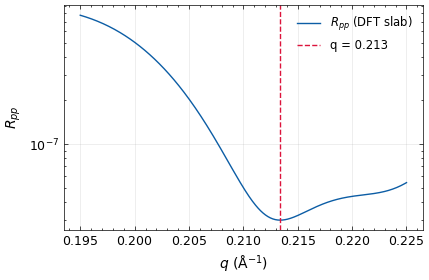

In [50]:
q_scan = np.linspace(0.195, 0.225, 401)
refl_dft, _ = uniaxial_reflectivity(q_scan, dft_layers, dft_tensor, ENERGY_EV)
r_pp_dft = refl_dft[:, 0, 0]

q_brewster = float(q_scan[np.argmin(r_pp_dft)])
print(
    f"Brewster q (R_pp minimum near 0.21): {q_brewster:.4f} A^-1  "
    f"R_pp = {r_pp_dft.min():.2e}"
)

fig_scan, ax_scan = plt.subplots(figsize=(4.5, 3.0))
ax_scan.semilogy(q_scan, r_pp_dft, label="$R_{pp}$ (DFT slab)")
ax_scan.axvline(
    q_brewster, color="crimson", lw=1.0, ls="--", label=f"q = {q_brewster:.3f}"
)
ax_scan.set_xlabel(r"$q$ ($\mathrm{\AA}^{-1}$)")
ax_scan.set_ylabel(r"$R_{pp}$")
ax_scan.legend(frameon=False, fontsize="small")
fig_scan.tight_layout()

In [51]:
# (q, depth) maps up to 20 A above the substrate; the display is later clipped
# at the SiO2 (oxide) top. depth from the first interface is depth = z_sub - z_above.
q_map = np.linspace(0.15, 0.255, 320)
z_above = np.linspace(0.0, 20.0, 400)  # angstrom above the Si substrate (z = 0)


def field_map_near_substrate(layers, tensor):
    """p-pol (q, depth) FieldMap over 0-20 A above this model's substrate."""
    z_sub = substrate_interface_depth(layers)
    fmap = uniaxial_field_map(q_map, layers, tensor, ENERGY_EV, "p", z_sub - z_above)
    return fmap, z_sub


map_dft, z_sub_dft = field_map_near_substrate(dft_layers, dft_tensor)
map_graded, z_sub_graded = field_map_near_substrate(graded_layers, graded_tensor)

# The oxide (SiO2) slab sits directly on the Si backing, so the SiO2 top sits at
# z = oxide thickness above the substrate. Clip everything below this line.
z_sio2_dft = float(dft_layers[-2, 0])
z_sio2_graded = float(graded_layers[-2, 0])
z_floor = max(z_sio2_dft, z_sio2_graded)

print(f"substrate interface: DFT {z_sub_dft:.1f} A  graded {z_sub_graded:.1f} A")
print(
    f"SiO2 top: DFT {z_sio2_dft:.2f} A  graded {z_sio2_graded:.2f} A  "
    f"floor {z_floor:.2f} A"
)
print(f"map shape (n_q, n_z): {map_dft.e_field.shape}")


def film_interfaces_above_oxide(
    layers, z_sub, z_oxide_top, *, zmax=20.0, min_sigma=0.5
):
    """(z_above_A, sigma_A) for real interfaces strictly above the SiO2 top.

    Zero-roughness microslab seams inside the sliced graded film
    (``sigma < min_sigma``) and everything at or below the oxide top are dropped.
    """
    depth = np.concatenate([[0.0], np.cumsum(layers[1:-1, 0])])
    sigma = layers[1:, 3]
    z = z_sub - depth
    keep = (z > z_oxide_top + 0.5) & (z <= zmax) & (sigma >= min_sigma)
    return list(zip(z[keep], sigma[keep], strict=True))


iface_dft = film_interfaces_above_oxide(dft_layers, z_sub_dft, z_sio2_dft)
iface_graded = film_interfaces_above_oxide(graded_layers, z_sub_graded, z_sio2_graded)
print("DFT film interfaces above oxide:",
      [(round(z, 1), round(s, 1)) for z, s in iface_dft])
print("graded film interfaces above oxide:",
      [(round(z, 1), round(s, 1)) for z, s in iface_graded])

substrate interface: DFT 206.5 A  graded 195.6 A
SiO2 top: DFT 6.88 A  graded 6.88 A  floor 6.88 A
map shape (n_q, n_z): (320, 400)
DFT film interfaces above oxide: [(np.float64(17.6), np.float64(7.9))]
graded film interfaces above oxide: []


In [52]:
def amplitude(fmap):
    """Normalized field strength ``|E| / |E_inc|`` from a FieldMap."""
    return np.sqrt(fmap.intensity)


def phase_deg(fmap):
    """Wrapped phase ``arg(E_x)`` in degrees, range (-180, 180]."""
    return np.degrees(np.angle(fmap.e_field))


# Restrict to the film above the SiO2 top so nothing below the oxide is drawn.
vis = z_above >= z_floor
z_vis = z_above[vis]

amp_dft = amplitude(map_dft)[:, vis]
amp_graded = amplitude(map_graded)[:, vis]
phase_dft = phase_deg(map_dft)[:, vis]
phase_graded = phase_deg(map_graded)[:, vis]

# amp_lo = float(min(amp_dft.min(), amp_graded.min()))
# amp_hi = float(max(amp_dft.max(), amp_graded.max()))
print(f"visible window z = {z_vis.min():.2f}-{z_vis.max():.2f} A")
print(f"|E|/|E_inc| range {amp_lo:.3f}-{amp_hi:.3f}")

visible window z = 6.92-20.00 A
|E|/|E_inc| range 0.974-1.000


saved /Users/hduva/projects/refl-analysis/notebooks/exploration/efield_phase_brewster.png


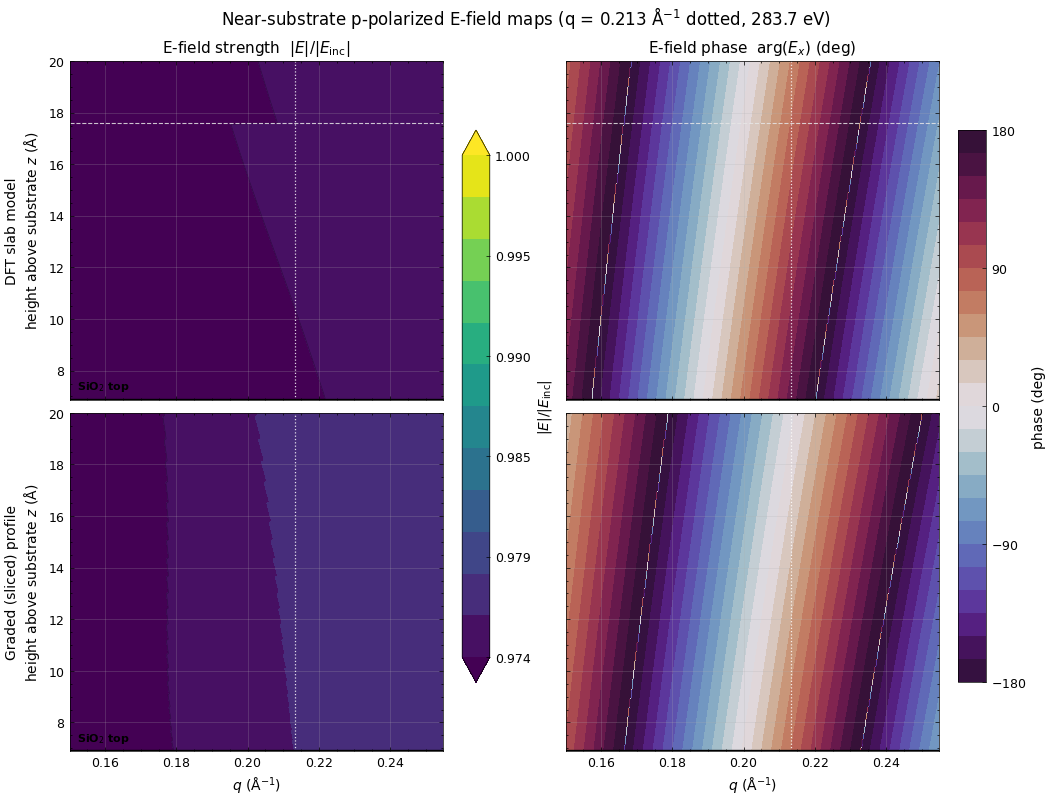

In [45]:
plt.rcParams.update({"font.size": 10})
amp_levels = np.linspace(amp_lo, amp_hi, 13)
phase_levels = np.linspace(-180.0, 180.0, 25)


def draw_amp(ax, data):
    """Filled + line contours of the field strength on the (q, z) grid."""
    cf = ax.contourf(
        q_map, z_vis, data.T, levels=amp_levels, cmap="viridis", extend="both"
    )
    ax.contour(
        q_map, z_vis, data.T, levels=amp_levels[::2],
        colors="k", linewidths=0.4, alpha=0.35,
    )
    return cf


def draw_phase(ax, data):
    """Filled contours of the wrapped phase (cyclic colormap)."""
    return ax.contourf(
        q_map, z_vis, data.T, levels=phase_levels, cmap="twilight_shifted"
    )


def annotate(ax, interfaces, *, show_xlabel):
    """Mark Brewster q, the bold SiO2 top, and film interfaces above it."""
    ax.axvline(q_brewster, color="w", lw=0.9, ls=":", alpha=0.85)
    ax.axhline(z_floor, color="k", lw=2.4)
    for z_i, _sig in interfaces:
        ax.axhline(z_i, color="0.9", lw=0.8, ls="--", alpha=0.85)
    ax.set_ylim(z_floor, float(z_vis.max()))
    if show_xlabel:
        ax.set_xlabel(r"$q$ ($\mathrm{\AA}^{-1}$)")


fig, axes = plt.subplots(
    2, 2, figsize=(10.5, 8.0), sharex=True, sharey=True, layout="constrained"
)

im_amp = draw_amp(axes[0, 0], amp_dft)
draw_amp(axes[1, 0], amp_graded)
draw_phase(axes[0, 1], phase_dft)
im_phase = draw_phase(axes[1, 1], phase_graded)

annotate(axes[0, 0], iface_dft, show_xlabel=False)
annotate(axes[0, 1], iface_dft, show_xlabel=False)
annotate(axes[1, 0], iface_graded, show_xlabel=True)
annotate(axes[1, 1], iface_graded, show_xlabel=True)

for ax in (axes[0, 0], axes[1, 0]):
    ax.text(
        q_map.min() + 0.002, z_floor + 0.25, r"SiO$_2$ top",
        color="k", fontsize=8, va="bottom", fontweight="bold",
    )

axes[0, 0].set_title(r"E-field strength  $|E| / |E_{\mathrm{inc}}|$")
axes[0, 1].set_title(r"E-field phase  $\arg(E_x)$ (deg)")
axes[0, 0].set_ylabel(
    "DFT slab model\n" + r"height above substrate $z$ ($\mathrm{\AA}$)"
)
axes[1, 0].set_ylabel(
    "Graded (sliced) profile\n" + r"height above substrate $z$ ($\mathrm{\AA}$)"
)

fig.colorbar(
    im_amp, ax=axes[:, 0], label=r"$|E|/|E_{\mathrm{inc}}|$", shrink=0.8,
    ticks=np.linspace(amp_lo, amp_hi, 6), format="%.3f",
)
fig.colorbar(
    im_phase, ax=axes[:, 1], label="phase (deg)", shrink=0.8,
    ticks=np.arange(-180, 181, 90),
)

fig.suptitle(
    "Near-substrate p-polarized E-field maps "
    f"(q = {q_brewster:.3f} " + r"$\mathrm{\AA}^{-1}$"
    + f" dotted, {ENERGY_EV:.1f} eV)",
    fontsize=12,
)
out_png = Path("efield_phase_brewster.png")
fig.savefig(out_png, dpi=200, bbox_inches="tight")
print("saved", out_png.resolve())

## Field and phase over the interface: slab vs graded (q = 0.22 inverse angstrom)

Real-space maps starting **at the SiO2 interface** (`zeta = 0`) and going up into
the film. The **x-axis is lateral position** in the film plane; the **y-axis is
distance from the SiO2 interface** (A). Columns are the p-polarized field
strength `|E| / |E_inc|` and the phase `arg(E_x)` (deg); rows are the DFT slab
and graded models.

The stacks are laterally uniform, so both `|E|` and the phase depend only on
depth (horizontal bands, the standing wave and its phase evolution as the wave
propagates up through the media). The only overlay is the **interface
boundary**: horizontal contours of the Nevot-Croce error-function-broadened
in-plane optical constant `Re(delta)`. For the slab model the interface contours
cluster tightly (sharp boundary); for the graded model they spread out (smooth
transition), each broadened by the interface roughness `sigma`.


q = 0.22 A^-1  |E|/|E_inc| 0.974-0.979  zeta 0..40 A above SiO2
saved /Users/hduva/projects/refl-analysis/notebooks/exploration/efield_structure_maps_q022.png


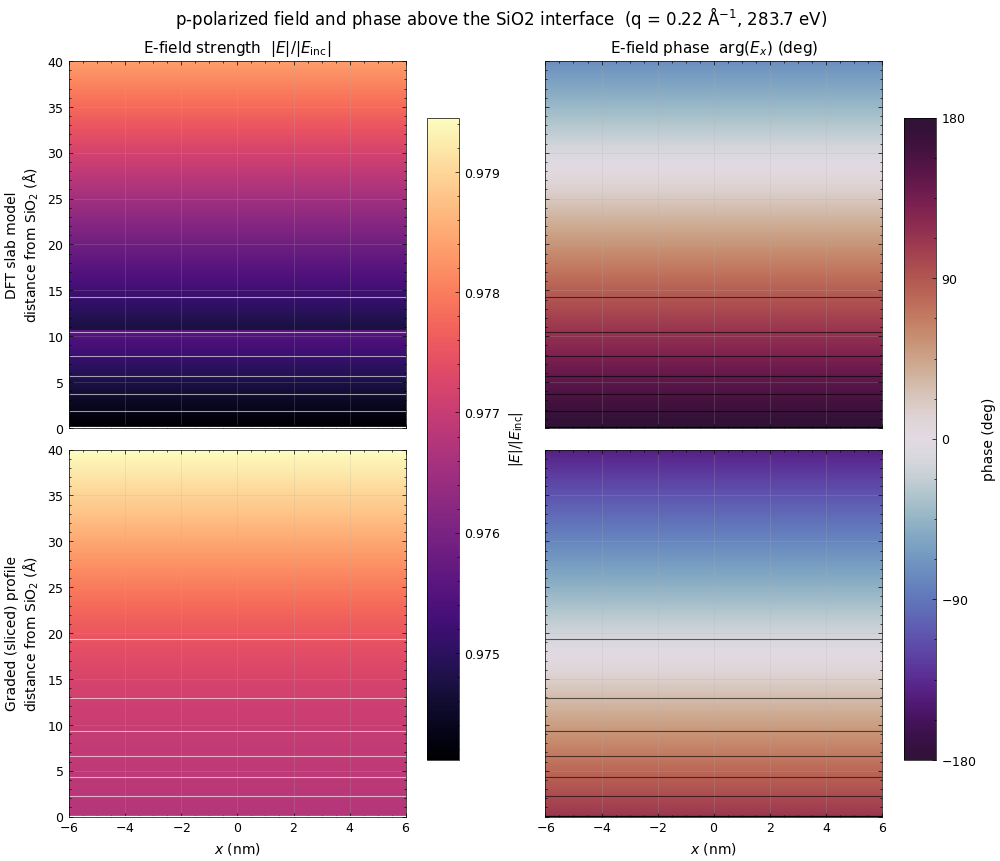

In [53]:
Q_SECOND = 0.22
zeta = np.linspace(0.0, 40.0, 400)  # distance above the SiO2 interface (A)
x_lat = np.linspace(-6.0, 6.0, 180)  # lateral position in the film plane (nm)


def field_maps(layers, tensor):
    """``|E| / |E_inc|`` and ``arg(E_x)`` (deg) vs ``zeta`` at ``Q_SECOND`` (p-pol)."""
    z_sub = substrate_interface_depth(layers)
    fmap = uniaxial_field_map(
        np.array([Q_SECOND]), layers, tensor, ENERGY_EV, "p", z_sub - (zeta + z_floor)
    )
    return np.sqrt(fmap.intensity)[0], np.degrees(np.angle(fmap.e_field))[0]


def nc_structure_profile(layers, tensor):
    """NC-broadened in-plane ``Re(delta)`` vs ``zeta``, normalized to ``[0, 1]``.

    Builds the error-function interface model
    ``delta(d) = delta_0 + sum_k 0.5 (delta_k - delta_{k-1})
    (1 + erf((d - D_k) / (sqrt(2) sigma_k)))`` from the per-layer optical
    constants and each interface's Nevot-Croce roughness ``sigma`` (column 3).
    """
    z_sub = substrate_interface_depth(layers)
    depth_q = z_sub - (zeta + z_floor)
    delta = np.real(tensor[:, 0, 0])
    sigma = layers[:, 3]
    boundaries = np.concatenate([[0.0], np.cumsum(layers[1:-1, 0])])
    profile = np.full_like(depth_q, delta[0])
    for k in range(1, delta.size):
        width = np.sqrt(2.0) * max(float(sigma[k]), 1e-6)
        profile += (
            (delta[k] - delta[k - 1])
            * 0.5
            * (1.0 + erf((depth_q - boundaries[k - 1]) / width))
        )
    span = float(profile.max() - profile.min())
    return np.zeros_like(profile) if span == 0.0 else (profile - profile.min()) / span


amp_dft_c, phase_dft_c = field_maps(dft_layers, dft_tensor)
amp_graded_c, phase_graded_c = field_maps(graded_layers, graded_tensor)
prof_dft = nc_structure_profile(dft_layers, dft_tensor)
prof_graded = nc_structure_profile(graded_layers, graded_tensor)

amp_lo_c = float(min(amp_dft_c.min(), amp_graded_c.min()))
amp_hi_c = float(max(amp_dft_c.max(), amp_graded_c.max()))
print(
    f"q = {Q_SECOND} A^-1  |E|/|E_inc| {amp_lo_c:.3f}-{amp_hi_c:.3f}  "
    f"zeta 0..{zeta.max():.0f} A above SiO2"
)

extent = (float(x_lat.min()), float(x_lat.max()), 0.0, float(zeta.max()))
struct_levels = np.linspace(0.15, 0.85, 6)


def tile2d(column):
    """Broadcast a depth-only profile across the lateral axis for imaging."""
    return np.tile(column[:, None], (1, x_lat.size))


fig_c, axes_c = plt.subplots(
    2, 2, figsize=(10.0, 8.6), sharex=True, sharey=True, layout="constrained"
)

for row, (amp, phase, prof, name) in enumerate(
    [
        (amp_dft_c, phase_dft_c, prof_dft, "DFT slab model"),
        (amp_graded_c, phase_graded_c, prof_graded, "Graded (sliced) profile"),
    ]
):
    ax_a, ax_p = axes_c[row, 0], axes_c[row, 1]
    im_amp = ax_a.imshow(
        tile2d(amp), origin="lower", extent=extent, aspect="auto",
        cmap="magma", vmin=amp_lo_c, vmax=amp_hi_c,
    )
    im_phase = ax_p.imshow(
        tile2d(phase), origin="lower", extent=extent, aspect="auto",
        cmap="twilight_shifted", vmin=-180.0, vmax=180.0,
    )
    for ax, ccolor in ((ax_a, "w"), (ax_p, "k")):
        ax.contour(
            x_lat, zeta, tile2d(prof), levels=struct_levels,
            colors=ccolor, linewidths=0.8, alpha=0.6,
        )
        ax.axhline(0.0, color=ccolor, lw=1.6)
    ax_a.set_ylabel(f"{name}\n" + r"distance from SiO$_2$ ($\mathrm{\AA}$)")

axes_c[0, 0].set_title(r"E-field strength  $|E| / |E_{\mathrm{inc}}|$")
axes_c[0, 1].set_title(r"E-field phase  $\arg(E_x)$ (deg)")
axes_c[1, 0].set_xlabel(r"$x$ (nm)")
axes_c[1, 1].set_xlabel(r"$x$ (nm)")

fig_c.colorbar(
    im_amp, ax=axes_c[:, 0], shrink=0.85, label=r"$|E| / |E_{\mathrm{inc}}|$"
)
fig_c.colorbar(
    im_phase, ax=axes_c[:, 1], shrink=0.85, label="phase (deg)",
    ticks=np.arange(-180, 181, 90),
)
fig_c.suptitle(
    f"p-polarized field and phase above the SiO2 interface  (q = {Q_SECOND:.2f} "
    + r"$\mathrm{\AA}^{-1}$" + f", {ENERGY_EV:.1f} eV)",
    fontsize=12,
)
out_png_c = Path("efield_structure_maps_q022.png")
fig_c.savefig(out_png_c, dpi=200, bbox_inches="tight")
print("saved", out_png_c.resolve())


tilt range slab 50.3-69.5 deg
tilt range graded 30.8-67.8 deg


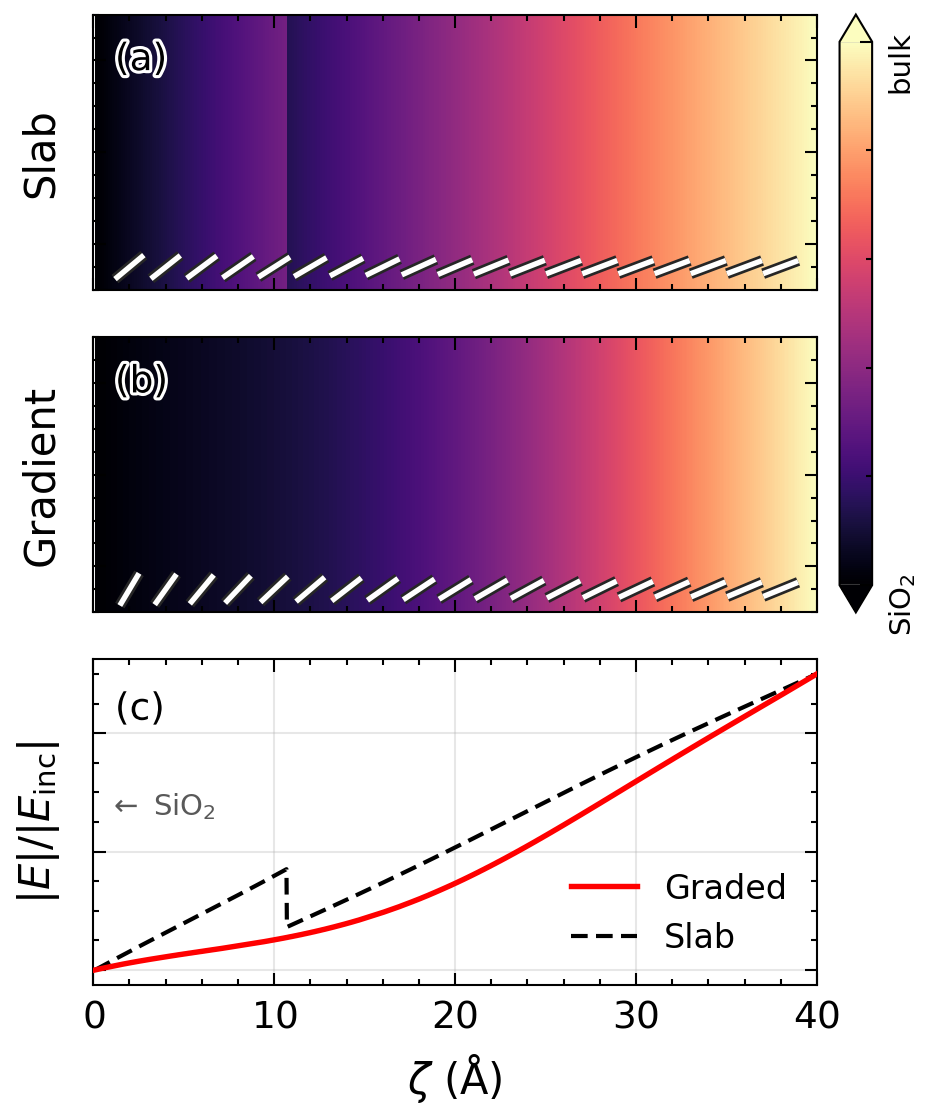

In [56]:
"""SI figure: p-pol E-field strength at the buried film/SiO2 interface.

Single PRL column (3.35 in). Two real-space |E|/|E_inc| distributions at
fixed q = Q_TRACE, rotated so zeta (A above the film/SiO2 interface) runs
horizontally and lateral x (nm) runs vertically: (a) DFT slab model,
(b) graded (sliced) profile. The molecular (TDM) tilt is overlaid on each
map as a row of oriented tick markers progressing through the layer; the
markers are drawn in display units, so the tilt angles are true regardless
of the panel aspect. Panel (c) is the line cut |E|(zeta) for both models on
the shared zeta axis.

Color normalization is anchored to the physical traversal of the window:
vmin is the Si-side intensity (left edge) and vmax the film-bulk intensity
(right edge), so the colormap spans exactly the interface-to-bulk range.

The tilt is taken from the models directly (fig_5 convention), not from the
optical tensor: the graded film via film.orientation(depth) so the bookended
profile reaches its true Si-side value, and the DFT slab from the per-slab
sld.rotation values erf-blended at the internal film interfaces. Inverting
the tensor anisotropy fails here because the isotropic non-resonant
background biases the recovered angle toward the magic angle. The window
ends at zeta = 0; nothing below the oxide is drawn, and no interface
overlays hide the slab-model discontinuity.

Only the data built by the loading cells of efield_phase_brewster.ipynb is
assumed in scope: ENERGY_EV, dft_layers, dft_tensor, graded_layers,
graded_tensor, dft_structure, graded_film.
"""

import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import gridspec, ticker
from scipy.special import erf

from utils.field_profile import substrate_interface_depth, uniaxial_field_map
from utils.helpers.plotting_helper import set_plotting_defaults

set_plotting_defaults()

# ── Configuration ────────────────────────────────────────────────────────────

Q_TRACE = 0.22                          # A^-1, single q for the whole figure
# Start a hair above zero to dodge the boundary-sample artifact visible as a
# vertical spike at the very first zeta sample.
zeta = np.linspace(0.1, 40.0, 1600)     # A above film/SiO2
x_nm = np.linspace(-3.0, 3.0, 240)      # lateral position (nm)

# Model identity carried by color across every panel (fig_5 convention).
C_GRADED, C_DFT = "r", "k"
LS_DFT = (0, (4, 2))

TICK_Z = np.arange(2.0, 39.0, 2.0)      # zeta positions of the tilt ticks (A)
TICK_SIZE = 9                           # tick marker length (points)

# ── Field reconstruction ─────────────────────────────────────────────────────


def stack_geometry(layers):
    """(z_sub, z_sio2): substrate depth and film/SiO2 height above Si."""
    z_sub = substrate_interface_depth(layers)
    z_sio2 = float(layers[-2, 0])
    return z_sub, z_sio2


def amp_on_zeta(layers, tensor):
    """|E|/|E_inc| vs zeta at Q_TRACE (p-pol), zeta = 0 at film/SiO2."""
    z_sub, z_sio2 = stack_geometry(layers)
    fmap = uniaxial_field_map(
        np.array([Q_TRACE]), layers, tensor, ENERGY_EV, "p", z_sub - (zeta + z_sio2)
    )
    return np.sqrt(fmap.intensity)[0]


def slab_gamma_on_zeta(structure, zeta_q, idx=(1, 2, 3)):
    """DFT-slab tilt (rad) at each zeta, from per-slab sld.rotation values.

    fig_5 convention (slab_film_profiles): erf-blended at the two internal
    film interfaces, in the film depth frame measured from the vacuum side;
    zeta above the film/SiO2 interface maps to depth = total - zeta.
    """
    s = [structure[i] for i in idx]
    t = np.array([float(c.thick.value) for c in s])
    a = np.array([float(c.sld.rotation.value) for c in s])
    r1 = max(float(s[1].rough.value), 1e-6)
    r2 = max(float(s[2].rough.value), 1e-6)
    depth = float(t.sum()) - np.asarray(zeta_q, dtype=float)
    step1 = 0.5 * (1.0 + erf((depth - t[0]) / (np.sqrt(2.0) * r1)))
    step2 = 0.5 * (1.0 + erf((depth - t[0] - t[1]) / (np.sqrt(2.0) * r2)))
    return a[0] + (a[1] - a[0]) * step1 + (a[2] - a[1]) * step2


def graded_gamma_on_zeta(film, zeta_q):
    """Graded-film tilt (rad) at each zeta, from the bookended profile.

    film.orientation takes depth from the film's vacuum interface, so the
    Si-side bookend value is reached as zeta -> 0.
    """
    total = float(film.total_thick.value)
    depth = total - np.asarray(zeta_q, dtype=float)
    return np.asarray(film.orientation(depth), dtype=float)


amp_s = amp_on_zeta(dft_layers, dft_tensor)
amp_g = amp_on_zeta(graded_layers, graded_tensor)
gam_s = slab_gamma_on_zeta(dft_structure, TICK_Z)
gam_g = graded_gamma_on_zeta(graded_film, TICK_Z)



# Interface-to-bulk color normalization: use values at zeta=0 (left, Si side)
# and zeta=40 (right, film bulk) for each amplitude profile

# Find indices closest to zeta == 0 and zeta == 40
_left_idx = np.abs(zeta - 0).argmin()
_right_idx = np.abs(zeta - 40).argmin()

# Get values at those locations for both amp_s and amp_g
amp_s_left = float(amp_s[_left_idx])
amp_s_right = float(amp_s[_right_idx])
amp_g_left = float(amp_g[_left_idx])
amp_g_right = float(amp_g[_right_idx])

# Scale both amp2d_s and amp2d_g to the range of amp_s_left and amp_s_right
amp_s = (amp_s - amp_s_left) / (amp_s_right - amp_s_left)
amp_g = (amp_g - amp_g_left) / (amp_g_right - amp_g_left)

# Rotated maps: rows are lateral x, columns are zeta. |E| is laterally
# uniform, so the distribution is the depth profile broadcast across x.
amp2d_s = np.tile(amp_s[None, :], (x_nm.size, 1))
amp2d_g = np.tile(amp_g[None, :], (x_nm.size, 1))

print(f"tilt range slab {np.degrees(gam_s).min():.1f}-{np.degrees(gam_s).max():.1f} deg")
print(f"tilt range graded {np.degrees(gam_g).min():.1f}-{np.degrees(gam_g).max():.1f} deg")

# ── Figure ───────────────────────────────────────────────────────────────────

FIG_W, FIG_H = 3.35, 4.2
fig = plt.figure(figsize=(FIG_W, FIG_H), dpi=300)
gs = gridspec.GridSpec(
    3, 2,
    figure=fig,
    width_ratios=[1.0, 0.045],
    height_ratios=[0.55, 0.55, 0.65],
    wspace=0.06,
    hspace=0.16,
)

ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[1, 0], sharex=ax_a, sharey=ax_a)
ax_c = fig.add_subplot(gs[2, 0], sharex=ax_a)
cax = fig.add_subplot(gs[0:2, 1])

extent = (float(zeta[0]), float(zeta[-1]), float(x_nm[0]), float(x_nm[-1]))
LETTER_FX = [pe.withStroke(linewidth=1.5, foreground="w")]
TICK_FX = [pe.withStroke(linewidth=2.6, foreground="0.15")]


def letter(ax, tag):
    ax.text(
        0.03, 0.90, tag,
        transform=ax.transAxes, ha="left", va="top", fontsize=9,
        path_effects=LETTER_FX,
    )


def overlay_tilt_ticks(ax, gammas):
    """Oriented tick markers along the map midline, one per TICK_Z.

    The (2, 0, angle) line marker renders in display units, so the drawn
    angle equals gamma from the vertical whatever the axes aspect is.
    """
    for z0, gam in zip(TICK_Z, gammas, strict=True):
        ax.plot(
            [z0], [-2.5],
            marker=(2, 0, -float(np.degrees(gam))),
            markersize=TICK_SIZE, markeredgewidth=1.3,
            markeredgecolor="w", linestyle="none",
            path_effects=TICK_FX, zorder=8,
        )


for ax, data, gammas, tag, name in (
    (ax_a, amp2d_s, gam_s, "(a)", "Slab"),
    (ax_b, amp2d_g, gam_g, "(b)", "Gradient"),
):
    im = ax.imshow(
        data, origin="lower", extent=extent, aspect="auto",
        cmap="magma", vmin=0, vmax=1, interpolation="nearest",
    )
    overlay_tilt_ticks(ax, gammas)
    ax.set_ylabel(name)
    ax.tick_params(labelbottom=False)
    ax.set_yticklabels([])
    ax.grid(False)
    letter(ax, tag)

cbar = fig.colorbar(im, cax=cax, extend="both")
cbar.update_ticks()
cax.tick_params(labelsize=7)
# Use ticks of bulk, SiO2 interface
cax.set_yticks([0, 1])
cax.set_yticklabels(["SiO$_2$", "bulk"], rotation=90)
cax.yaxis.offsetText.set_fontsize(7)

# ── (c) line cut on the shared zeta axis ─────────────────────────────────────

ax_c.plot(zeta, amp_g, color=C_GRADED, ls="-", lw=1.3, zorder=6, label="Graded")
ax_c.plot(zeta, amp_s, color=C_DFT, ls=LS_DFT, lw=1.0, zorder=4, label="Slab")
ax_c.set_ylabel(r"$|E| / |E_{\mathrm{inc}}|$")
ax_c.set_xlabel(r"$\zeta$ ($\mathrm{\AA}$)")
ax_c.set_xlim(0.0, float(zeta[-1]))
ax_c.yaxis.set_major_locator(ticker.MaxNLocator(3))
ax_c.set_yticklabels([])
ax_c.legend(loc="lower right")

# The oxide sits just beyond the left edge at zeta = 0.
ax_c.text(
    0.02, 0.5, r"$\leftarrow$ SiO$_2$",
    transform=ax_c.transAxes, ha="left", va="bottom",
    fontsize=7, color="0.35",
)

# # Direct labels on the curves instead of a legend box.
# i_lbl = int(0.72 * zeta.size)
# pad = 0.06 * (amp_hi - amp_lo)
# ax_c.text(
#     zeta[i_lbl]+pad, amp_g[i_lbl] + pad, "graded",
#     color=C_GRADED, fontsize=8, ha="center", va="bottom",
# )
# ax_c.text(
#     zeta[i_lbl] - pad, amp_s[i_lbl] - pad, "DFT slab",
#     color=C_DFT, fontsize=8, ha="center", va="top",
# )
letter(ax_c, "(c)")

fig.savefig(
    "efield_interface_distribution.png",
    dpi=300, bbox_inches="tight", transparent=True,
)
fig.savefig(
    "efield_interface_distribution.pdf",
    dpi=300, bbox_inches="tight", transparent=True,
)
plt.show()